# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

[I 2026-04-08 13:53:59,635] A new study created in memory with name: no-name-5f7cb8f2-a3e6-4f9a-90c8-ddfb56733470
[I 2026-04-08 13:53:59,716] Trial 0 finished with value: 0.7258064516129032 and parameters: {'n_estimators': 121, 'max_depth': 3}. Best is trial 0 with value: 0.7258064516129032.
[I 2026-04-08 13:53:59,887] Trial 1 finished with value: 0.732824427480916 and parameters: {'n_estimators': 205, 'max_depth': 12}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,070] Trial 2 finished with value: 0.6942148760330579 and parameters: {'n_estimators': 222, 'max_depth': 7}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,208] Trial 3 finished with value: 0.7166666666666667 and parameters: {'n_estimators': 181, 'max_depth': 6}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,382] Trial 4 finished with value: 0.7424242424242424 and parameters: {'n_estimators': 200, 'max_depth': 14}. Best is trial 4 with value: 0.74242424242

RF F1: 0.7368421052631579
LR F1: 0.71875
SVM F1: 0.736
KNN F1: 0.7555555555555555


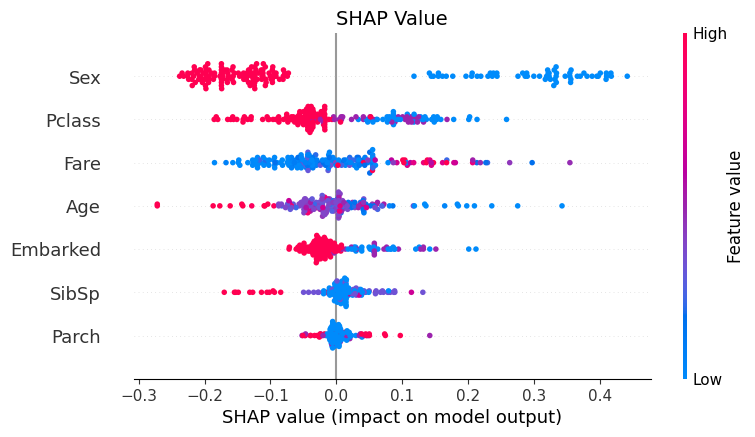

Stacking F1: 0.765625


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [14]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])


# split
train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42)

from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.

,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(8000, 11)"
4,Transformed data shape,"(8000, 11)"
5,Transformed train set shape,"(5600, 11)"
6,Transformed test set shape,"(2400, 11)"
7,Numeric features,10
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.8641,0.8583,0.4839,0.7701,0.5934,0.5170,0.5376,1.2230
lightgbm,Light Gradient Boosting Machine,0.8579,0.8495,0.4935,0.7287,0.5869,0.5051,0.5199,0.1260
gbc,Gradient Boosting Classifier,0.8643,0.8565,0.4614,0.7912,0.5812,0.5073,0.5343,0.1330
xgboost,Extreme Gradient Boosting,0.8507,0.8346,0.4996,0.6895,0.5787,0.4909,0.5007,0.0340
ada,Ada Boost Classifier,0.8568,0.8389,0.4735,0.7352,0.5747,0.4937,0.5117,0.0570
rf,Random Forest Classifier,0.8580,0.8393,0.4588,0.7541,0.5691,0.4904,0.5128,0.1320
et,Extra Trees Classifier,0.8507,0.8344,0.4344,0.7291,0.5441,0.4618,0.4840,0.0970
dt,Decision Tree Classifier,0.7868,0.6865,0.5161,0.4829,0.4986,0.3635,0.3640,0.0100
qda,Quadratic Discriminant Analysis,0.8366,0.8107,0.3189,0.7379,0.4445,0.3661,0.4109,0.0100
lr,Logistic Regression,0.8116,0.7381,0.1868,0.6494,0.2892,0.2171,0.2742,0.8330


In [7]:
# 데이터 로드
import pandas as pd
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 데이터 전처리 또는 EDA (전처리 기법 왜 그것을 썼는지, 그래프 Draw하고 해석)

df.head() # 데이터 확인

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.info() # 결측치 확인과 dtype확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [11]:
# 범주형 encoding
# gender, country 컬럼도 모델을 돌리기 위해서 object dtype 컬럼을 encording 시행함.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender']) # gender 컬럼 encording
print(le.classes_)

['Female' 'Male']


In [12]:
df['country'] = le.fit_transform(df['country']) # country 컬럼 encording
print(le.classes_)

['France' 'Germany' 'Spain']


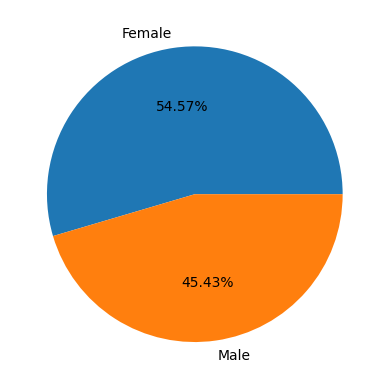

In [13]:
import matplotlib.pyplot as plt
gender = df.gender.value_counts()
plt.pie(gender, labels = ['Female', 'Male'], autopct="%.2f%%")
plt.show()

<BarContainer object of 3 artists>

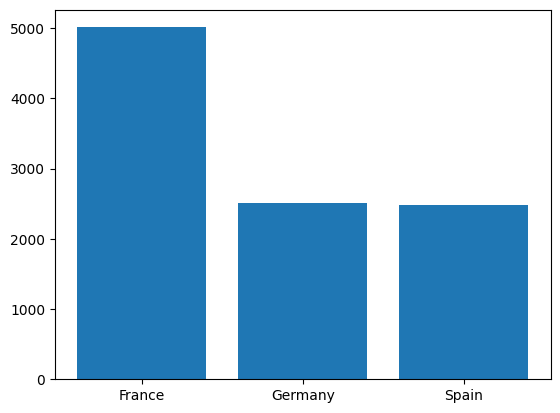

In [14]:
country = df.country.value_counts()
plt.bar(['France', 'Germany', 'Spain'], country)

In [15]:
print(df.age.min())
print(len(df[df["age"] < 20]))
print(len(df[(df["age"] >= 20) & (df["age"] < 30)]))
print(len(df[(df["age"] >= 30) & (df["age"] < 40)]))
print(len(df[(df["age"] < 50) & (df["age"] >= 40)]))
print(len(df[(df["age"] >= 50) & (df["age"] < 60)]))
print(len(df[df["age"] >= 60 ]))

# 나이대 분포 확인

18
49
1592
4346
2618
869
526


In [16]:
# 성별비중을 봤을 때 Female이 남성보다 약 10% 정도 많음
# France, Germany, Spain중 France의 고객이 압도적으로 비중이 높음
# 나이대는 10대가 10000명으로 압도적으로 비중이 높음
# 상품 특성과 은행 특성을 파악해 France 고객이 많은 이유와 나이 10대의 고객이 많은 이유를 찾아보아야 할 필요가 있어 보인다.

In [19]:
# 상위모델 4개 고른 것을, 각 모델 optuna로 최적의 파라미터 찾기
# (옵션 리스트는 구글 검색 필요 할 것)

# 모델은 pycaset를 통해 얻은 상위모델 CatBoost Classifier, Gradient Boosting Classifier, xgboost, Ada Boost Classifier로 선정

# X, y 데이터 나누기
# 분석하는 의미없는 uniqu한 값을 가진 customer_id는 제외
# 컬럼마다 이탈여부에 대해 알아보기 위해 정답값(y)을 'churn'으로 설정

X = df.drop(["customer_id", "churn"], axis = 1)
y = df['churn']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

import optuna

# 옵튜마로 CatBoost Classifier, Gradient Boosting Classifier, xgboost, Ada Boost Classifier의 파라미터를 튜닝.
def objective_catboost(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),    # 옵튜나에게 n_estimators를 100~300범위로 요청
        'depth': trial.suggest_int('depth', 4, 10)  # 옵튜나에게 depth를 4~10 범위로 요청
    }
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train) # 모델 학습

    pred = model.predict(X_valid)   # valid 데이터로 모델 예측값 도출
    return f1_score(y_valid, pred)  # 예측값과 valid 정답값으로 f1_score계산

def objective_gbc(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),    # 옵튜나에게 n_estimators를 100~300범위로 요청
        'max_depth': trial.suggest_int('max_depth', 3, 10)  # 옵튜나에게 max_depth를 3~10 범위로 요청
    }
    model = GradientBoostingClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),    # 옵튜나에게 n_estimators를 100~300범위로 요청
        'max_depth': trial.suggest_int('max_depth', 3, 10)  # 옵튜나에게 max_depth를 3~10 범위로 요청
    }
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_ada(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300), # 옵튜나에게 n_estimators를 50~300범위로 요청
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0)    ## 옵튜나에게 learning_rate 를 0.01~1.0 범위로 요청
    }
    model = AdaBoostClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 탐색할 함수에서 return 받는 수치를 maximize
# n_trials에서 설정한 만큼 탐색
study_catboost = optuna.create_study(direction = 'maximize')
study_catboost.optimize(objective_catboost, n_trials=10)

study_gbc = optuna.create_study(direction = 'maximize')
study_gbc.optimize(objective_gbc, n_trials=10)

study_xgb = optuna.create_study(direction = 'maximize')
study_xgb.optimize(objective_xgb, n_trials=10)

study_ada = optuna.create_study(direction = 'maximize')
study_ada.optimize(objective_ada, n_trials=10)

# 최적의 파라미터를 모델에 집어넣기
catboost = CatBoostClassifier(**study_catboost.best_params)
gbc = GradientBoostingClassifier(**study_gbc.best_params)
xgb = XGBClassifier(**study_xgb.best_params)
ada = AdaBoostClassifier(**study_ada.best_params)

# 최적 파라미터를 넣은 모델가지고 fitting 시키기
catboost.fit(X_train, y_train)
gbc.fit(X_train, y_train)
xgb.fit(X_train, y_train)
ada.fit(X_train, y_train)

# 각 모델의 f1-score 출력하기
for name, model in [('CAT', catboost), ('GBC', gbc), ('XGB', xgb), ('ADA', ada)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

[I 2026-04-10 13:33:07,655] A new study created in memory with name: no-name-1d12d6d0-67d6-4152-9208-02b3d99cb496


Learning rate set to 0.079665
0:	learn: 0.6309192	total: 170ms	remaining: 47.9s
1:	learn: 0.5796219	total: 175ms	remaining: 24.6s
2:	learn: 0.5405579	total: 181ms	remaining: 16.9s
3:	learn: 0.5128586	total: 186ms	remaining: 13s
4:	learn: 0.4817440	total: 191ms	remaining: 10.6s
5:	learn: 0.4566823	total: 195ms	remaining: 8.99s
6:	learn: 0.4383228	total: 199ms	remaining: 7.83s
7:	learn: 0.4227170	total: 202ms	remaining: 6.94s
8:	learn: 0.4099713	total: 205ms	remaining: 6.24s
9:	learn: 0.4004171	total: 207ms	remaining: 5.66s
10:	learn: 0.3924479	total: 210ms	remaining: 5.2s
11:	learn: 0.3856673	total: 213ms	remaining: 4.81s
12:	learn: 0.3793258	total: 215ms	remaining: 4.47s
13:	learn: 0.3747049	total: 218ms	remaining: 4.18s
14:	learn: 0.3697250	total: 220ms	remaining: 3.94s
15:	learn: 0.3662056	total: 223ms	remaining: 3.72s
16:	learn: 0.3634289	total: 226ms	remaining: 3.54s
17:	learn: 0.3582797	total: 229ms	remaining: 3.37s
18:	learn: 0.3564620	total: 231ms	remaining: 3.21s
19:	learn: 0.3

[I 2026-04-10 13:33:08,821] Trial 0 finished with value: 0.6048632218844985 and parameters: {'n_estimators': 283, 'depth': 6}. Best is trial 0 with value: 0.6048632218844985.


270:	learn: 0.2446008	total: 988ms	remaining: 43.7ms
271:	learn: 0.2443268	total: 991ms	remaining: 40.1ms
272:	learn: 0.2440412	total: 994ms	remaining: 36.4ms
273:	learn: 0.2437300	total: 998ms	remaining: 32.8ms
274:	learn: 0.2434856	total: 1s	remaining: 29.1ms
275:	learn: 0.2431774	total: 1s	remaining: 25.5ms
276:	learn: 0.2430051	total: 1.01s	remaining: 21.9ms
277:	learn: 0.2426558	total: 1.01s	remaining: 18.2ms
278:	learn: 0.2422315	total: 1.02s	remaining: 14.6ms
279:	learn: 0.2420153	total: 1.02s	remaining: 10.9ms
280:	learn: 0.2418019	total: 1.02s	remaining: 7.3ms
281:	learn: 0.2416339	total: 1.03s	remaining: 3.65ms
282:	learn: 0.2414617	total: 1.03s	remaining: 0us
Learning rate set to 0.076214
0:	learn: 0.6334426	total: 4.52ms	remaining: 1.34s
1:	learn: 0.5837537	total: 9.29ms	remaining: 1.37s
2:	learn: 0.5455220	total: 13.3ms	remaining: 1.31s
3:	learn: 0.5181919	total: 17.5ms	remaining: 1.28s
4:	learn: 0.4873098	total: 21.7ms	remaining: 1.27s
5:	learn: 0.4622078	total: 26ms	rema

[I 2026-04-10 13:33:09,729] Trial 1 finished with value: 0.5978755690440061 and parameters: {'n_estimators': 297, 'depth': 6}. Best is trial 0 with value: 0.6048632218844985.


...

209:	learn: 0.1855436	total: 1s	remaining: 157ms
210:	learn: 0.1851635	total: 1s	remaining: 152ms
211:	learn: 0.1844400	total: 1.01s	remaining: 148ms
212:	learn: 0.1839684	total: 1.01s	remaining: 143ms
213:	learn: 0.1835000	total: 1.02s	remaining: 138ms
214:	learn: 0.1831146	total: 1.02s	remaining: 133ms
215:	learn: 0.1825509	total: 1.03s	remaining: 128ms
216:	learn: 0.1819929	total: 1.03s	remaining: 124ms
217:	learn: 0.1817131	total: 1.04s	remaining: 119ms
218:	learn: 0.1812904	total: 1.04s	remaining: 114ms
219:	learn: 0.1808415	total: 1.05s	remaining: 109ms
220:	learn: 0.1805300	total: 1.05s	remaining: 105ms
221:	learn: 0.1801887	total: 1.05s	remaining: 99.9ms
222:	learn: 0.1797159	total: 1.06s	remaining: 95.1ms
223:	learn: 0.1793486	total: 1.06s	remaining: 90.3ms
224:	learn: 0.1789162	total: 1.07s	remaining: 85.5ms
225:	learn: 0.1782750	total: 1.07s	remaining: 80.7ms
226:	learn: 0.1778753	total: 1.08s	remaining: 76ms
227:	learn: 0.1776309	total: 1.08s	remaining: 71.2ms
228:	learn: 0

[I 2026-04-10 13:33:29,025] Trial 0 finished with value: 0.5761194029850746 and parameters: {'n_estimators': 246, 'max_depth': 5}. Best is trial 0 with value: 0.5761194029850746.
[I 2026-04-10 13:33:34,153] Trial 1 finished with value: 0.5658682634730539 and parameters: {'n_estimators': 131, 'max_depth': 10}. Best is trial 0 with value: 0.5761194029850746.
[I 2026-04-10 13:33:37,934] Trial 2 finished with value: 0.5850746268656717 and parameters: {'n_estimators': 240, 'max_depth': 5}. Best is trial 2 with value: 0.5850746268656717.
[I 2026-04-10 13:33:39,376] Trial 3 finished with value: 0.6029850746268657 and parameters: {'n_estimators': 121, 'max_depth': 4}. Best is trial 3 with value: 0.6029850746268657.
[I 2026-04-10 13:33:42,143] Trial 4 finished with value: 0.5942684766214178 and parameters: {'n_estimators': 226, 'max_depth': 4}. Best is trial 3 with value: 0.6029850746268657.
[I 2026-04-10 13:33:45,478] Trial 5 finished with value: 0.5468053491827637 and parameters: {'n_estimato

Learning rate set to 0.079665
0:	learn: 0.6309192	total: 6.13ms	remaining: 1.73s
1:	learn: 0.5796219	total: 13.4ms	remaining: 1.89s
2:	learn: 0.5405579	total: 19.3ms	remaining: 1.8s
3:	learn: 0.5128586	total: 23.8ms	remaining: 1.66s
4:	learn: 0.4817440	total: 28.5ms	remaining: 1.58s
5:	learn: 0.4566823	total: 31.9ms	remaining: 1.47s
6:	learn: 0.4383228	total: 35ms	remaining: 1.38s
7:	learn: 0.4227170	total: 37.6ms	remaining: 1.29s
8:	learn: 0.4099713	total: 40.2ms	remaining: 1.22s
9:	learn: 0.4004171	total: 42.9ms	remaining: 1.17s
10:	learn: 0.3924479	total: 45.8ms	remaining: 1.13s
11:	learn: 0.3856673	total: 48.3ms	remaining: 1.09s
12:	learn: 0.3793258	total: 50.8ms	remaining: 1.05s
13:	learn: 0.3747049	total: 52.8ms	remaining: 1.01s
14:	learn: 0.3697250	total: 55.5ms	remaining: 991ms
15:	learn: 0.3662056	total: 58.5ms	remaining: 976ms
16:	learn: 0.3634289	total: 61.3ms	remaining: 959ms
17:	learn: 0.3582797	total: 63.8ms	remaining: 940ms
18:	learn: 0.3564620	total: 66.3ms	remaining: 9

c:\Users\campus4D010\anaconda3\envs\imbk8\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


CAT F1: 0.6048632218844985
GBC F1: 0.6029850746268657
XGB F1: 0.5961251862891207
ADA F1: 0.5771604938271605


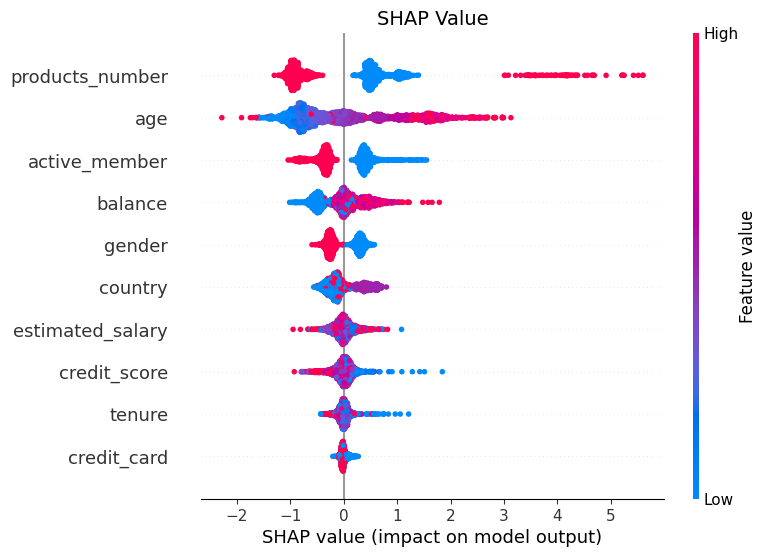

In [21]:
# 모델 4개 중 1개 잡아서 SHAP Value 시각화 하기 (교재 내용 적용 요망, 도움 요청 가능)

import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import StackingClassifier

# CatBoost모델을 지정해서 shap values 출력
explainer = shap.TreeExplainer(catboost)
shap_values = explainer.shap_values(X_valid)

if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()

In [22]:
# SHAP value 사후분석
# churn 이탈여부 : 0 = 유지, 1 = 이탈
# - products_number: 3집군으로 나뉘어서 뚜렷하게 분류가 된 것으로 보임. 은행에서 이용 중인 상품 수가 낮을수록 이탈률 높다고 보임.
#                       상품 수가 높으면 이탈하지하고 유지하는 쪽으로 몰려있는 것으로 확인되지만, 일부는 이탈률이 높다고 측정됨. 상품수가 높으나 이탈률이 높은 데이터를 살펴보아 특징을 알아볼 필요가 있음.
# - age: 나이대가 낮을 수록 이탈률이 낮은 것으로 확인됨. 특정 연령대가 선호하는 상품을 보유중인지, 전연령대가 쓰기 적합하지 않은 상품인지 확인할 필요가 있음.
# - active_member: 비활성이면 이탈, 활성이면 유지로 확인.
# - balance: 분포가 계좌잔액이 낮을 수록 유지하는 것을 확인됨. 고잔액보유 고객이 이탈하는 이유가 무엇인지 찾아야한다.
# - gender: 뚜렷하게 남여로 나뉘어 분포되어있음을 확인. 은행유지고객이 한 성별로 쏠린것으로 확인 됨.
# - country ['France': 0 'Germany': 1 'Spain': 2]: France 고객이 주로 유지하는 것으로 확인 되며, Germany의 고객이 이탈률이 높은 것으로 확인됨.
#                                                France에 최적화된 은행으로 볼 수 있을것이다. 다른나라의 이탈을 줄이기 위해 고안을 해보아야할 것임.
# - estimated_salary: 골고루 분포되어있음.
# - credit_score: 골고루 분포되어있음
# - tenure: 이탈률에 크게 영향을 주지 않는 것으로 보임.
# - credit_card: 이탈률에 영향이 거의 없는것으로 보임.

In [23]:
# 4개 모델을 Stacking (전방모델, 후방모델 아무거나) F1 SCORE, accuracy_score 출력
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

est_model_list = [
                      ('cat', catboost),
                      ('gbc', gbc),
                      ('ada', ada)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = XGBClassifier() # 후방모델
)

# stacking 모델 fitting하기
stack.fit(X_train, y_train)

# fitting한 모델로 예측값 뽑기
pred = stack.predict(X_valid)

# 정답값과 예측값과의 f1_score출력
print("Stacking F1:", f1_score(y_valid, pred))

Learning rate set to 0.079665
0:	learn: 0.6309192	total: 4.25ms	remaining: 1.2s
1:	learn: 0.5796219	total: 7.82ms	remaining: 1.1s
2:	learn: 0.5405579	total: 11.9ms	remaining: 1.11s
3:	learn: 0.5128586	total: 16.1ms	remaining: 1.12s
4:	learn: 0.4817440	total: 20.9ms	remaining: 1.16s
5:	learn: 0.4566823	total: 24.1ms	remaining: 1.11s
6:	learn: 0.4383228	total: 27.5ms	remaining: 1.08s
7:	learn: 0.4227170	total: 31.2ms	remaining: 1.07s
8:	learn: 0.4099713	total: 35ms	remaining: 1.07s
9:	learn: 0.4004171	total: 38.3ms	remaining: 1.04s
10:	learn: 0.3924479	total: 41.5ms	remaining: 1.03s
11:	learn: 0.3856673	total: 45.2ms	remaining: 1.02s
12:	learn: 0.3793258	total: 48.7ms	remaining: 1.01s
13:	learn: 0.3747049	total: 51.4ms	remaining: 987ms
14:	learn: 0.3697250	total: 54.7ms	remaining: 977ms
15:	learn: 0.3662056	total: 57.9ms	remaining: 967ms
16:	learn: 0.3634289	total: 61.4ms	remaining: 961ms
17:	learn: 0.3582797	total: 64.7ms	remaining: 953ms
18:	learn: 0.3564620	total: 68.4ms	remaining: 95

c:\Users\campus4D010\anaconda3\envs\imbk8\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Learning rate set to 0.072424
0:	learn: 0.6367615	total: 4.72ms	remaining: 1.33s
1:	learn: 0.6007685	total: 7.67ms	remaining: 1.08s
2:	learn: 0.5605984	total: 12.8ms	remaining: 1.2s
3:	learn: 0.5274395	total: 16.9ms	remaining: 1.18s
4:	learn: 0.5032489	total: 20.3ms	remaining: 1.13s
5:	learn: 0.4776727	total: 24ms	remaining: 1.11s
6:	learn: 0.4608607	total: 27.5ms	remaining: 1.08s
7:	learn: 0.4478144	total: 30.1ms	remaining: 1.03s
8:	learn: 0.4316469	total: 32.6ms	remaining: 993ms
9:	learn: 0.4188418	total: 35ms	remaining: 955ms
10:	learn: 0.4114486	total: 36.7ms	remaining: 907ms
11:	learn: 0.4030717	total: 39.1ms	remaining: 882ms
12:	learn: 0.3955603	total: 41.8ms	remaining: 868ms
13:	learn: 0.3883306	total: 44ms	remaining: 846ms
14:	learn: 0.3820317	total: 46.3ms	remaining: 827ms
15:	learn: 0.3757921	total: 48.4ms	remaining: 807ms
16:	learn: 0.3717603	total: 50.7ms	remaining: 793ms
17:	learn: 0.3698964	total: 52.1ms	remaining: 767ms
18:	learn: 0.3666312	total: 54.2ms	remaining: 753ms

c:\Users\campus4D010\anaconda3\envs\imbk8\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\campus4D010\anaconda3\envs\imbk8\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\campus4D010\anaconda3\envs\imbk8\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\campus4D010\anaconda3\envs\imbk8\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME

Stacking F1: 0.5714285714285714
